# Age of Information: sending updates faster can make your data *staler*

A monitoring agent, an IoT sensor, a cache refresher, a replication stream — all push **status
updates** to a consumer. The intuitive rule is "update more often to stay fresh." Queueing theory
says there is a catch: past a point, sending *more* updates makes the freshest data the consumer
holds **older**, not newer, because the updates queue up behind each other.

The right metric is the **Age of Information** (AoI): how old is the newest delivered update. It has
a **U-shape** in the update rate — there is an optimal rate, and both under- and over-sending hurt.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.theory.aoi import AoICalc

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})
MU = 1.0  # the channel/processor serves one update per unit time on average

def avg_aoi(lam):
    c = AoICalc()
    c.set_sources(lam)       # update generation (arrival) rate
    c.set_servers(mu=MU)     # M/M/1 delivery
    return c.run().avg_aoi


## The freshness U-curve

For an M/M/1 update channel the time-average age is
`Δ = (1/μ)(1 + 1/ρ + ρ²/(1-ρ))`, with `ρ = λ/μ`.
- Send too **rarely** (`λ→0`): each delivered update is fresh, but between updates the age grows for
  a long time — average age is high.
- Send too **often** (`λ→μ`): updates congest the queue; by the time one is delivered it is already
  stale — average age blows up again.

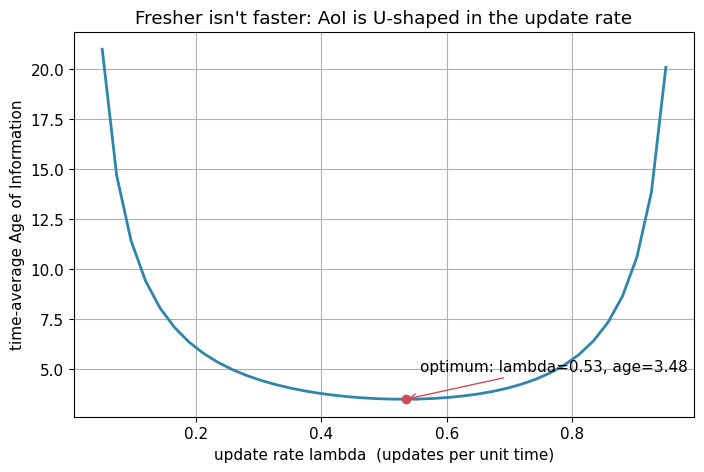

optimal update rate lambda ~ 0.53 (utilization ~ 53%)

  lambda=0.10: average age = 11.01

  lambda=0.30: average age = 4.46

  lambda=0.53: average age = 3.48

  lambda=0.80: average age = 5.45

  lambda=0.95: average age = 20.10

In [2]:
lams = np.linspace(0.05, 0.95, 40)
ages = [avg_aoi(l) for l in lams]
opt_i = int(np.argmin(ages))
opt_lam, opt_age = lams[opt_i], ages[opt_i]

fig, ax = plt.subplots()
ax.plot(lams, ages, color="#2e86ab", lw=2)
ax.scatter([opt_lam], [opt_age], color="#d1495b", zorder=5)
ax.annotate(f"optimum: lambda={opt_lam:.2f}, age={opt_age:.2f}",
            (opt_lam, opt_age), textcoords="offset points", xytext=(10, 20),
            arrowprops=dict(arrowstyle="->", color="#d1495b"))
ax.set_xlabel("update rate lambda  (updates per unit time)")
ax.set_ylabel("time-average Age of Information")
ax.set_title("Fresher isn't faster: AoI is U-shaped in the update rate")
plt.show()

print(f"optimal update rate lambda ~ {opt_lam:.2f} (utilization ~ {opt_lam/MU:.0%})")
for lam in [0.1, 0.3, opt_lam, 0.8, 0.95]:
    print(f"  lambda={lam:.2f}: average age = {avg_aoi(lam):.2f}")


**The insight.** The lowest average age is reached at a **moderate** update rate (~55% channel
utilization for M/M/1), **not** at the maximum. Flooding the channel (λ close to μ) is as bad as
barely updating — the freshest data the receiver has is old either way. "More updates = fresher" is
simply false once queueing is involved.

## The waiting-time trap doesn't tell you this

Note the optimum for *age* (~55% load) is different from what you'd pick to minimize *waiting time*
(as low a load as possible). Freshness is not the same objective as latency: an update that waits in
the queue makes everything behind it stale, so age penalizes over-sending in a way raw latency does
not. If your goal is fresh data (dashboards, control loops, replication lag, cache TTLs), optimize
AoI, not throughput or per-message latency.

A smarter discipline helps too: **preemptive-LCFS** (always serve the newest update, discard stale
ones) keeps age low and stays stable at any rate — the library's `LcfsPreemptiveAoICalc`.

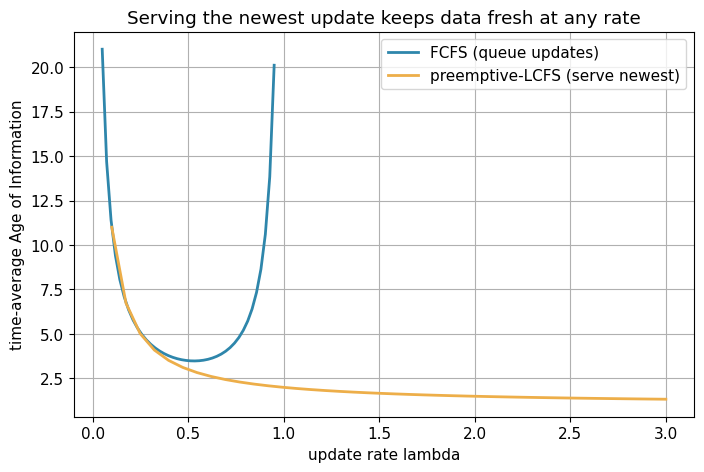

In [3]:
from most_queue.theory.aoi import LcfsPreemptiveAoICalc

def lcfs_age(lam):
    c = LcfsPreemptiveAoICalc()
    c.set_sources(lam)
    c.set_servers(mu=MU)
    return c.run().avg_aoi

lams2 = np.linspace(0.1, 3.0, 40)   # LCFS-PR is stable even for lambda > mu
fig, ax = plt.subplots()
ax.plot(lams, ages, color="#2e86ab", lw=2, label="FCFS (queue updates)")
ax.plot(lams2, [lcfs_age(l) for l in lams2], color="#edae49", lw=2, label="preemptive-LCFS (serve newest)")
ax.set_xlabel("update rate lambda")
ax.set_ylabel("time-average Age of Information")
ax.set_title("Serving the newest update keeps data fresh at any rate")
ax.legend()
plt.show()


**The insight.** Preemptive-LCFS keeps the age low and **monotonically improving** as you send
faster — because a fresh update simply discards the stale one in service instead of waiting behind
it. Same channel, different scheduling, completely different freshness behaviour.

## Takeaways

- Freshness (**Age of Information**) is U-shaped in the update rate: there is an **optimal** rate,
  and over-sending makes data staler, not fresher.
- Freshness ≠ latency ≠ throughput — optimize the metric you actually care about.
- If you control the discipline, "always serve the newest" (preemptive-LCFS) beats FCFS for
  freshness and never destabilizes.

See the [Age of Information models](../docs/models.md) and the
[trends survey](../docs/research/queueing-trends-2026.md).